# CICIDS 2017 Network Intrusion Detection — LWCE Loss Comparison

PyTorch MLP on CICIDS 2017 (15-class: BENIGN + 14 attack types).  
Comparing 7 loss functions: `ce`, `wce`, `pwce`, `lwce`, `plwce`, `cb`, `focal`.

In [1]:
# Cell 0: Environment + Setup
!pip install -q torch torchvision optuna pandas openpyxl scikit-learn kagglehub

import os, sys, gc, json, warnings, importlib.util, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import GridSampler

warnings.filterwarnings('ignore')

# ── GitHub repo ───────────────────────────────────────────────────
REPO_PATH = '/content/imbalanced-data-LWCE'
if not os.path.exists(REPO_PATH):
    print('Cloning...')
    !git clone https://github.com/gseungho/imbalanced-data-LWCE.git {REPO_PATH}

# ── Load classification loss functions ───────────────────────────
get_clf_loss = None
try:
    spec = importlib.util.spec_from_file_location(
        'clf', f'{REPO_PATH}/image_classification/custom_losses.py'
    )
    clf_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(clf_module)
    get_clf_loss = clf_module.get_clf_loss
    print('✓ Loss functions loaded!')
except Exception as e:
    print(f'Warning: {e}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Constants ─────────────────────────────────────────────────────
DATASET_NAME       = 'CICIDS2017'
NUM_CLASSES        = 15
BATCH_SIZE         = 512
FINAL_EPOCHS       = 50
PROXY_EPOCHS       = 10
PROXY_SUBSET_RATIO = 0.20
TARGET_TOTAL       = 300_000   # 전체 subset 크기
BENIGN_MAX         = 100_000   # BENIGN 클래스 최대 샘플 수
RESULTS_DIR = '/content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/CICIDS2017'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Results dir: {RESULTS_DIR}')

✓ Loss functions loaded!
Device: cuda
Results dir: /content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/CICIDS2017


In [2]:
# Cell 1: Load & Preprocess CICIDS 2017
import kagglehub

def load_cicids2017():
    print('Downloading CICIDS 2017...')
    path = kagglehub.dataset_download('chethuhn/network-intrusion-dataset')
    print(f'Dataset path: {path}')

    # 모든 CSV 파일 로드 (요일별 파일 존재)
    csv_files = sorted(glob.glob(f'{path}/**/*.csv', recursive=True))
    if not csv_files:
        csv_files = sorted(glob.glob(f'{path}/*.csv'))
    print(f'CSV files found: {len(csv_files)}')
    for f in csv_files:
        print(f'  {os.path.basename(f)}')

    dfs = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, encoding='utf-8',  low_memory=False)
        except UnicodeDecodeError:
            df = pd.read_csv(f, encoding='latin-1', low_memory=False)
        dfs.append(df)
        print(f'  Loaded {os.path.basename(f)}: {len(df):,} rows')
    df = pd.concat(dfs, axis=0, ignore_index=True)
    print(f'\nTotal rows: {len(df):,}')

    # 레이블 컬럼 정규화 (공백 제거)
    label_col = [c for c in df.columns if 'label' in c.lower()][0]
    df['label'] = df[label_col].astype(str).str.strip()

    # 피처 컬럼 = 레이블 제외 나머지 (숫자형만)
    feature_cols = [c for c in df.columns if c != label_col]
    # inf / -inf → NaN → 제거
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    before = len(df)
    df = df.dropna(subset=feature_cols)
    print(f'Dropped {before - len(df):,} rows with inf/NaN')

    # 숫자형 피처만 사용
    num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    print(f'Numeric features: {len(num_cols)}')

    # ── Stratified Subset (BENIGN 상한 + 전체 300K) ────────────────
    print('\nBuilding stratified subset...')
    unique_labels = df['label'].unique()
    benign_label  = next((l for l in unique_labels
                          if 'benign' in l.lower() or 'normal' in l.lower()),
                         unique_labels[0])
    non_benign_budget = TARGET_TOTAL - BENIGN_MAX
    non_benign_total  = (df['label'] != benign_label).sum()

    idx_list = []
    for lbl in unique_labels:
        mask = df['label'] == lbl
        idx  = df.index[mask].tolist()
        if lbl == benign_label:
            take = min(len(idx), BENIGN_MAX)
        else:
            # 비율 유지 (최소 50개 보장)
            prop = len(idx) / max(non_benign_total, 1)
            take = max(50, min(len(idx), int(prop * non_benign_budget)))
        sampled = np.random.choice(idx, min(take, len(idx)), replace=False)
        idx_list.extend(sampled.tolist())

    df_sub = df.loc[idx_list].reset_index(drop=True)
    print(f'Subset size: {len(df_sub):,}')

    # LabelEncoder
    le = LabelEncoder()
    df_sub['class'] = le.fit_transform(df_sub['label'])
    class_names_enc = le.classes_.tolist()
    num_cls         = len(class_names_enc)
    print(f'Classes ({num_cls}): {class_names_enc}')

    X = df_sub[num_cols].values.astype(np.float32)
    y = df_sub['class'].values.astype(np.int64)

    # Train / Val / Test = 70 : 15 : 15
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42
    )

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_val  = scaler.transform(X_val)
    X_te   = scaler.transform(X_te)

    class_counts = [int((y_tr == i).sum()) for i in range(num_cls)]
    input_dim    = X_tr.shape[1]

    print(f'\n✓ Loaded: Train={len(X_tr):,}, Val={len(X_val):,}, Test={len(X_te):,}')
    print(f'Input dim: {input_dim}')
    print('\nClass distribution (train):')
    for i, (name, cnt) in enumerate(zip(class_names_enc, class_counts)):
        pct = cnt / sum(class_counts) * 100
        print(f'  {i:2d} {name:35s}: {cnt:6,d} ({pct:.2f}%)')
    ir = max(class_counts) / max(min(c for c in class_counts if c > 0), 1)
    print(f'Imbalance ratio: {ir:.0f}:1')

    return (X_tr, X_val, X_te, y_tr, y_val, y_te,
            class_counts, input_dim, class_names_enc, num_cls)

def make_loaders(X_tr, X_val, X_te, y_tr, y_val, y_te, batch_size):
    def ds(X, y):
        return TensorDataset(torch.tensor(X, dtype=torch.float32),
                             torch.tensor(y, dtype=torch.long))
    train_loader = DataLoader(ds(X_tr,  y_tr),  batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(ds(X_val, y_val), batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(ds(X_te,  y_te),  batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

(X_tr, X_val, X_te, y_tr, y_val, y_te,
 class_counts, INPUT_DIM, CLASS_NAMES, NUM_CLASSES) = load_cicids2017()

train_loader, val_loader, test_loader = make_loaders(
    X_tr, X_val, X_te, y_tr, y_val, y_te, BATCH_SIZE
)

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Dataset path: /kaggle/input/network-intrusion-dataset
CSV files found: 8
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Wednesday-workingHours.pcap_ISCX.csv
  Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows
  Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows
  Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows
  Loaded Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows
  Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows
  Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows
  Loaded Tuesday-WorkingHours.pcap_

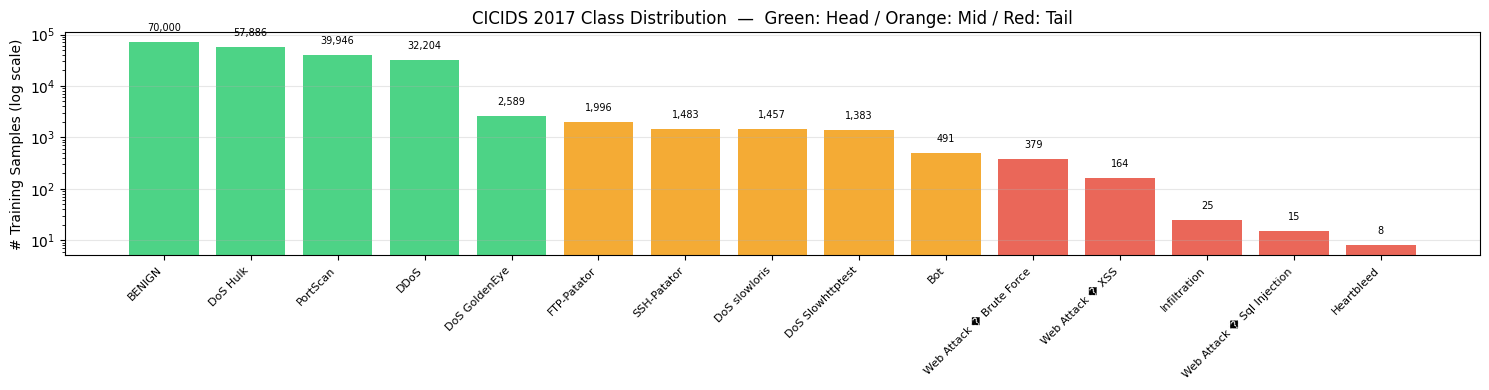

Head (≥2138): 5 classes
Mid  (448–2138): 5 classes
Tail (<448): 5 classes


In [3]:
# Cell 2: Class Distribution Visualization
def visualize_distribution(class_counts, class_names, title, save_path):
    counts = np.array(class_counts)
    order  = np.argsort(counts)[::-1]
    q1, q3 = np.percentile(counts, [33, 66])
    colors = ['#2ecc71' if c >= q3 else '#f39c12' if c >= q1 else '#e74c3c'
              for c in counts[order]]

    fig, ax = plt.subplots(figsize=(max(12, len(class_names)), 4))
    ax.bar(range(len(class_names)), counts[order], color=colors, alpha=0.85)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels([class_names[i] for i in order],
                       rotation=45, ha='right', fontsize=8)
    ax.set_yscale('log')
    ax.set_ylabel('# Training Samples (log scale)')
    ax.set_title(f'{title}  —  Green: Head / Orange: Mid / Red: Tail')
    ax.grid(True, alpha=0.3, axis='y')
    for i, c in enumerate(counts[order]):
        ax.text(i, c * 1.5, f'{c:,}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

    q1_val, q3_val = np.percentile(counts, [33, 66])
    head = sum(1 for c in counts if c >= q3_val)
    mid  = sum(1 for c in counts if q1_val <= c < q3_val)
    tail = sum(1 for c in counts if c < q1_val)
    print(f'Head (≥{q3_val:.0f}): {head} classes')
    print(f'Mid  ({q1_val:.0f}–{q3_val:.0f}): {mid} classes')
    print(f'Tail (<{q1_val:.0f}): {tail} classes')

visualize_distribution(
    class_counts, CLASS_NAMES,
    'CICIDS 2017 Class Distribution',
    f'{RESULTS_DIR}/class_distribution.png'
)

In [4]:
# Cell 3: MLP Model + Evaluation Functions

class MLP(nn.Module):
    """3-hidden-layer MLP with BatchNorm + Dropout."""
    def __init__(self, input_dim, num_classes,
                 hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def build_mlp():
    return MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)


def compute_metrics(model, loader, class_counts):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds = model(X_b.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    labels = list(range(NUM_CLASSES))
    per_f1 = f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0)

    counts = np.array(class_counts)
    q1, q3 = np.percentile(counts, [33, 66])
    head_idx = [i for i in range(NUM_CLASSES) if counts[i] >= q3]
    mid_idx  = [i for i in range(NUM_CLASSES) if q1 <= counts[i] < q3]
    tail_idx = [i for i in range(NUM_CLASSES) if counts[i] < q1]

    return {
        'Accuracy':          float(accuracy_score(y_true, y_pred)),
        'Balanced_Accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'F1_Macro':          float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
        'F1_Weighted':       float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'Per_Class_F1':      per_f1.tolist(),
        'Head_F1': float(per_f1[head_idx].mean()) if head_idx else 0.0,
        'Mid_F1':  float(per_f1[mid_idx].mean())  if mid_idx  else 0.0,
        'Tail_F1': float(per_f1[tail_idx].mean()) if tail_idx else 0.0,
    }

print('✓ MLP and evaluation functions defined')

✓ MLP and evaluation functions defined


In [5]:
# Cell 4: train_model() — definition only, not executed here

def train_model(loss_name, class_counts, tr_loader, val_loader,
                alpha=1.0, gamma=2.0, epochs=FINAL_EPOCHS):
    model = build_mlp()

    if get_clf_loss is not None:
        criterion = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5, min_lr=1e-6
    )

    history      = {'train_loss': [], 'val_F1_Macro': []}
    best_F1_Macro = 0.0
    best_state   = None

    print(f"\n{'='*50}\nTraining {loss_name.upper()} "
          f"(α={alpha:.2f}, γ={gamma:.2f})\n{'='*50}")

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits   = model(X_b)
            loss     = criterion(logits, y_b)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / max(n_batches, 1)
        history['train_loss'].append(avg_loss)

        metrics  = compute_metrics(model, val_loader, class_counts)
        bal_acc  = metrics['F1_Macro']
        history['val_F1_Macro'].append(bal_acc)
        scheduler.step(bal_acc)

        if bal_acc > best_F1_Macro:
            best_F1_Macro = bal_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | '
                  f'BalAcc: {bal_acc:.4f}')

    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    print(f'✓ {loss_name.upper()} best F1-Macro: {best_F1_Macro:.4f}')
    return model, history, best_F1_Macro

print('✓ train_model defined (not executed yet)')

✓ train_model defined (not executed yet)


In [6]:
# Cell 5: Optuna Hyperparameter Search
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TQDM_DISABLE'] = '1'

def _make_proxy_loader(ratio=PROXY_SUBSET_RATIO):
    n   = int(len(train_loader.dataset) * ratio)
    idx = np.random.choice(len(train_loader.dataset), n, replace=False)
    return DataLoader(Subset(train_loader.dataset, idx),
                     batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

def _cleanup(model=None):
    if model is not None:
        del model
    gc.collect()
    torch.cuda.empty_cache()

print(f'Optuna search (proxy: {PROXY_EPOCHS} epochs, {PROXY_SUBSET_RATIO*100:.0f}% subset)\n')
optuna_best = {}
proxy_loader = _make_proxy_loader()

# ── PWCE: alpha [0.5, 5.0] ────────────────────────────────────────
N_PWCE = 20
study_pwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(0.5, 5.0, N_PWCE).tolist()})
)
def obj_pwce(trial):
    alpha = trial.suggest_float('alpha', 0.5, 5.0)
    model, _, score = train_model('pwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_pwce.optimize(obj_pwce, n_trials=N_PWCE)
best_pwce = study_pwce.best_params
optuna_best['pwce'] = best_pwce
print(f'✓ PWCE  best: alpha={best_pwce["alpha"]:.2f}  (BalAcc={study_pwce.best_value:.4f})')

# ── PLWCE: alpha [1.0, 10.0] ─────────────────────────────────────
N_PLWCE = 20
study_plwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(1.0, 10.0, N_PLWCE).tolist()})
)
def obj_plwce(trial):
    alpha = trial.suggest_float('alpha', 1.0, 10.0)
    model, _, score = train_model('plwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_plwce.optimize(obj_plwce, n_trials=N_PLWCE)
best_plwce = study_plwce.best_params
optuna_best['plwce'] = best_plwce
print(f'✓ PLWCE best: alpha={best_plwce["alpha"]:.2f}  (BalAcc={study_plwce.best_value:.4f})')

# ── FOCAL: gamma [0.5, 5.0] ──────────────────────────────────────
N_FOCAL = 20
study_focal = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'gamma': np.linspace(0.5, 5.0, N_FOCAL).tolist()})
)
def obj_focal(trial):
    gamma = trial.suggest_float('gamma', 0.5, 5.0)
    model, _, score = train_model('focal', class_counts, proxy_loader, val_loader,
                                  gamma=gamma, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_focal.optimize(obj_focal, n_trials=N_FOCAL)
best_focal = study_focal.best_params
optuna_best['focal'] = best_focal
print(f'✓ FOCAL best: gamma={best_focal["gamma"]:.2f}  (BalAcc={study_focal.best_value:.4f})')

print(f'\nOptuna Results:\n{json.dumps(optuna_best, indent=2)}')

Optuna search (proxy: 10 epochs, 20% subset)


Training PWCE (α=4.76, γ=2.00)
Epoch 10/10 | Loss: 1.1876 | BalAcc: 0.0748
✓ PWCE best F1-Macro: 0.0834

Training PWCE (α=0.74, γ=2.00)
Epoch 10/10 | Loss: 0.3298 | BalAcc: 0.5970
✓ PWCE best F1-Macro: 0.5995

Training PWCE (α=5.00, γ=2.00)
Epoch 10/10 | Loss: 0.8817 | BalAcc: 0.0778
✓ PWCE best F1-Macro: 0.0923

Training PWCE (α=2.39, γ=2.00)
Epoch 10/10 | Loss: 0.6570 | BalAcc: 0.0694
✓ PWCE best F1-Macro: 0.1598

Training PWCE (α=2.87, γ=2.00)
Epoch 10/10 | Loss: 0.7158 | BalAcc: 0.0546
✓ PWCE best F1-Macro: 0.0775

Training PWCE (α=4.53, γ=2.00)
Epoch 10/10 | Loss: 0.7083 | BalAcc: 0.0676
✓ PWCE best F1-Macro: 0.0858

Training PWCE (α=1.92, γ=2.00)
Epoch 10/10 | Loss: 0.6276 | BalAcc: 0.1780
✓ PWCE best F1-Macro: 0.1780

Training PWCE (α=3.58, γ=2.00)
Epoch 10/10 | Loss: 0.5961 | BalAcc: 0.0799
✓ PWCE best F1-Macro: 0.0946

Training PWCE (α=1.45, γ=2.00)
Epoch 10/10 | Loss: 0.6287 | BalAcc: 0.4338
✓ PWCE best F1-Macro: 0.4584

Training

In [7]:
# Cell 6: Full Experiment (N_SEEDS seeds)
import random

N_SEEDS       = 5
LOSS_CONFIGS  = ['ce', 'wce', 'pwce', 'lwce', 'plwce', 'cb', 'focal']
seed_results   = {ln: [] for ln in LOSS_CONFIGS}
seed_histories = {ln: [] for ln in LOSS_CONFIGS}

print(f"\n{'='*60}")
print(f'FULL EXPERIMENT: {FINAL_EPOCHS} epochs × {len(LOSS_CONFIGS)} losses × {N_SEEDS} seeds')
print(f"{'='*60}")

for seed in range(N_SEEDS):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"\n{'─'*25}  Seed {seed}  {'─'*25}")

    for loss_name in LOSS_CONFIGS:
        alpha = optuna_best.get(loss_name, {}).get('alpha', 1.0)
        gamma = optuna_best.get('focal', {}).get('gamma', 2.0) if loss_name == 'focal' else 2.0

        model, history, _ = train_model(
            loss_name, class_counts, train_loader, val_loader,
            alpha=alpha, gamma=gamma, epochs=FINAL_EPOCHS
        )
        metrics = compute_metrics(model, test_loader, class_counts)
        seed_results[loss_name].append(metrics)
        seed_histories[loss_name].append(history)
        _cleanup(model)

print(f"\n{'='*60}")
print('✓ Full experiment completed!')
print(f"{'='*60}")


FULL EXPERIMENT: 50 epochs × 7 losses × 5 seeds

─────────────────────────  Seed 0  ─────────────────────────

Training CE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.0806 | BalAcc: 0.6687
Epoch 20/50 | Loss: 0.0721 | BalAcc: 0.6918
Epoch 30/50 | Loss: 0.0692 | BalAcc: 0.6912
Epoch 40/50 | Loss: 0.0672 | BalAcc: 0.6961
Epoch 50/50 | Loss: 0.0591 | BalAcc: 0.7930
✓ CE best F1-Macro: 0.7930

Training WCE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.3883 | BalAcc: 0.6755
Epoch 20/50 | Loss: 0.3781 | BalAcc: 0.6664
Epoch 30/50 | Loss: 0.2922 | BalAcc: 0.6782
Epoch 40/50 | Loss: 0.2781 | BalAcc: 0.7060
Epoch 50/50 | Loss: 0.2591 | BalAcc: 0.7386
✓ WCE best F1-Macro: 0.7386

Training PWCE (α=0.50, γ=2.00)
Epoch 10/50 | Loss: 0.1416 | BalAcc: 0.7142
Epoch 20/50 | Loss: 0.1245 | BalAcc: 0.7444
Epoch 30/50 | Loss: 0.1098 | BalAcc: 0.7695
Epoch 40/50 | Loss: 0.0981 | BalAcc: 0.7682
Epoch 50/50 | Loss: 0.0904 | BalAcc: 0.7729
✓ PWCE best F1-Macro: 0.7771

Training LWCE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 


EXPERIMENT SUMMARY (mean ± std, N=5)
Loss                Bal_Acc           F1_Macro            Head_F1            Tail_F1
ce            0.8191±0.0006      0.8082±0.0029      0.9900±0.0010      0.4965±0.0085
wce           0.8377±0.0018      0.7412±0.0062      0.9757±0.0024      0.4098±0.0192
pwce          0.8408±0.0006      0.7741±0.0049      0.9851±0.0010      0.4511±0.0081
lwce          0.8177±0.0095      0.7976±0.0070      0.9896±0.0013      0.4596±0.0244
plwce         0.8510±0.0075      0.7818±0.0098      0.9816±0.0019      0.4909±0.0324
cb            0.8390±0.0144      0.7711±0.0144      0.9842±0.0009      0.4475±0.0444
focal         0.8174±0.0017      0.8008±0.0036      0.9864±0.0019      0.4830±0.0116


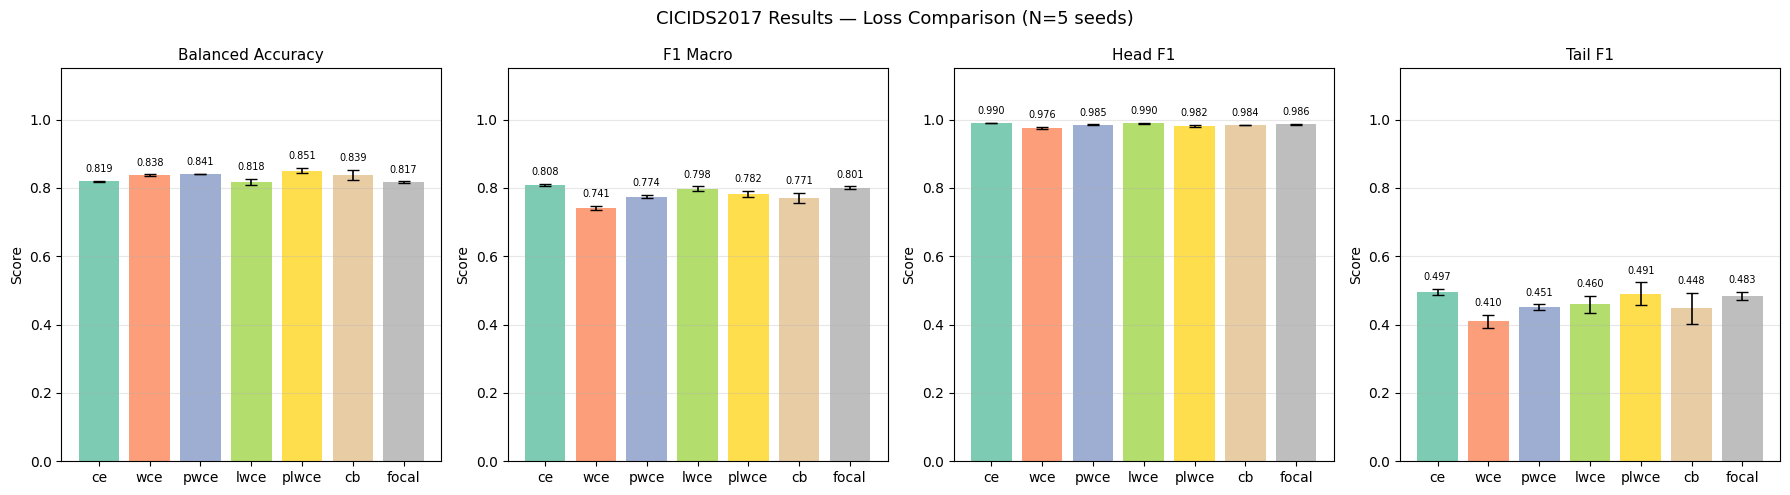

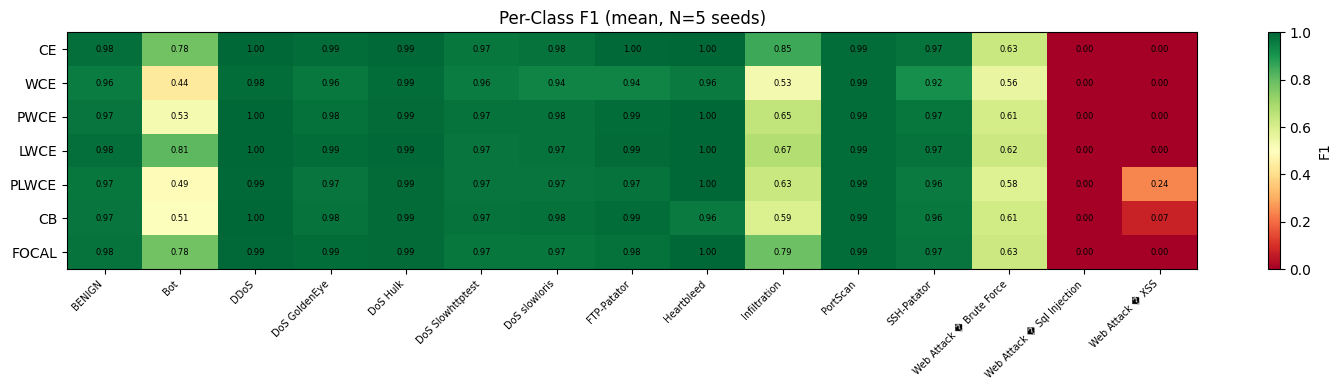

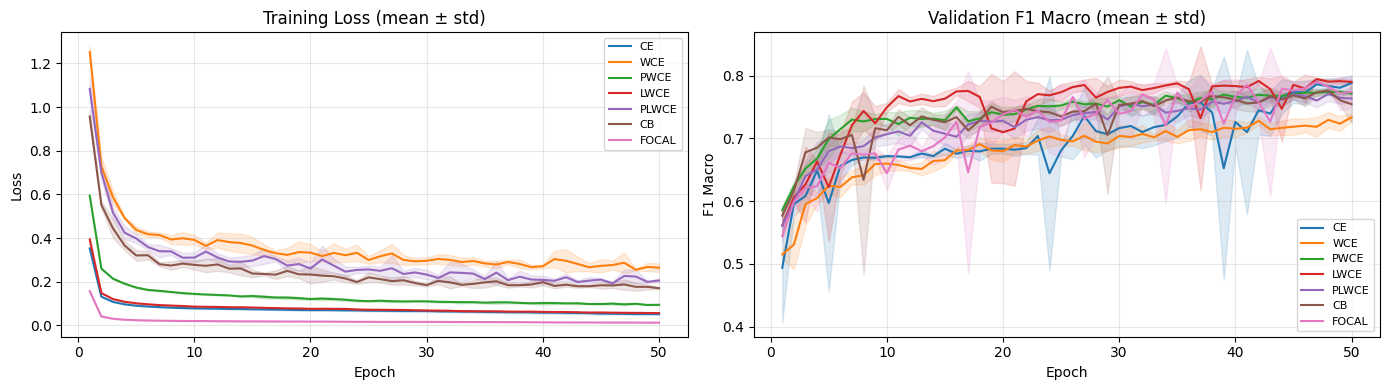

✓ Saved JSON
✓ Saved Excel

FINAL SUMMARY (mean ± std, N=5)
 Loss Balanced_Accuracy      F1_Macro       Head_F1       Tail_F1
   ce     0.8191±0.0006 0.8082±0.0029 0.9900±0.0010 0.4965±0.0085
  wce     0.8377±0.0018 0.7412±0.0062 0.9757±0.0024 0.4098±0.0192
 pwce     0.8408±0.0006 0.7741±0.0049 0.9851±0.0010 0.4511±0.0081
 lwce     0.8177±0.0095 0.7976±0.0070 0.9896±0.0013 0.4596±0.0244
plwce     0.8510±0.0075 0.7818±0.0098 0.9816±0.0019 0.4909±0.0324
   cb     0.8390±0.0144 0.7711±0.0144 0.9842±0.0009 0.4475±0.0444
focal     0.8174±0.0017 0.8008±0.0036 0.9864±0.0019 0.4830±0.0116


In [8]:
# Cell 7: Aggregate + Visualize + Save Results
METRIC_KEYS = ['Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Mid_F1', 'Tail_F1', 'Accuracy', 'F1_Weighted']
loss_names  = LOSS_CONFIGS

# ── Aggregate mean ± std ──────────────────────────────────────────
agg = {}
for ln in loss_names:
    agg[ln] = {}
    for k in METRIC_KEYS:
        vals = [r[k] for r in seed_results[ln]]
        agg[ln][k] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals))}
    per_cls_all = np.array([r['Per_Class_F1'] for r in seed_results[ln]])
    agg[ln]['Per_Class_F1_mean'] = per_cls_all.mean(axis=0).tolist()
    agg[ln]['Per_Class_F1_std']  = per_cls_all.std(axis=0).tolist()

# ── Summary print ─────────────────────────────────────────────────
def ms(ln, k): return f"{agg[ln][k]['mean']:.4f}±{agg[ln][k]['std']:.4f}"

print(f"\n{'='*60}\nEXPERIMENT SUMMARY (mean ± std, N={N_SEEDS})\n{'='*60}")
W = 17
print(f"{'Loss':8s}  {'Bal_Acc':>{W}}  {'F1_Macro':>{W}}  {'Head_F1':>{W}}  {'Tail_F1':>{W}}")
for ln in loss_names:
    print(f"{ln:8s}  {ms(ln,'Balanced_Accuracy'):>{W}}  {ms(ln,'F1_Macro'):>{W}}  {ms(ln,'Head_F1'):>{W}}  {ms(ln,'Tail_F1'):>{W}}")

# ── Bar chart with error bars ─────────────────────────────────────
colors = plt.cm.Set2(np.linspace(0, 1, len(loss_names)))
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'{DATASET_NAME} Results — Loss Comparison (N={N_SEEDS} seeds)', fontsize=13)
for ax, key, title in zip(
    axes,
    ['Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Tail_F1'],
    ['Balanced Accuracy',  'F1 Macro', 'Head F1', 'Tail F1']
):
    means = [agg[ln][key]['mean'] for ln in loss_names]
    stds  = [agg[ln][key]['std']  for ln in loss_names]
    bars  = ax.bar(loss_names, means, color=colors, alpha=0.85)
    ax.errorbar(loss_names, means, yerr=stds,
                fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class F1 heatmap (mean over seeds) ────────────────────────
per_cls_mat = np.array([agg[ln]['Per_Class_F1_mean'] for ln in loss_names])
fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES), 4))
im = ax.imshow(per_cls_mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(loss_names)))
ax.set_yticklabels([ln.upper() for ln in loss_names])
ax.set_title(f'Per-Class F1 (mean, N={N_SEEDS} seeds)')
plt.colorbar(im, ax=ax, label='F1')
for i in range(len(loss_names)):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{per_cls_mat[i,j]:.2f}', ha='center', va='center', fontsize=6)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Training curves (mean ± std band) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_x = np.arange(1, FINAL_EPOCHS + 1)
for ln in loss_names:
    loss_arr = np.array([h['train_loss']   for h in seed_histories[ln]])
    f1_arr   = np.array([h['val_F1_Macro'] for h in seed_histories[ln]])
    for ax, arr in zip(axes, [loss_arr, f1_arr]):
        m, s = arr.mean(axis=0), arr.std(axis=0)
        line, = ax.plot(epochs_x, m, label=ln.upper())
        ax.fill_between(epochs_x, m - s, m + s, alpha=0.15, color=line.get_color())
for ax, title, ylabel in zip(axes,
    ['Training Loss (mean ± std)', 'Validation F1 Macro (mean ± std)'],
    ['Loss', 'F1 Macro']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save JSON ─────────────────────────────────────────────────────
fname = DATASET_NAME.lower().replace('-', '').replace(' ', '_')
results_json = {
    'metadata': {
        'dataset':      DATASET_NAME,
        'model':        'MLP (256-128-64, BatchNorm, Dropout=0.3)',
        'num_classes':  NUM_CLASSES,
        'class_names':  CLASS_NAMES,
        'final_epochs': FINAL_EPOCHS,
        'batch_size':   BATCH_SIZE,
        'n_seeds':      N_SEEDS,
        'optuna_best':  optuna_best,
        'class_counts': class_counts,
    },
    'aggregated': agg,
    'per_seed':   {ln: seed_results[ln] for ln in loss_names},
}
with open(f'{RESULTS_DIR}/{fname}_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print('✓ Saved JSON')

# ── Save Excel ────────────────────────────────────────────────────
summary_rows = []
for ln in loss_names:
    row = {'Loss': ln}
    for k in METRIC_KEYS:
        row[f'{k}_mean'] = round(agg[ln][k]['mean'], 4)
        row[f'{k}_std']  = round(agg[ln][k]['std'],  4)
        row[k]           = f"{agg[ln][k]['mean']:.4f}±{agg[ln][k]['std']:.4f}"
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)

per_class_df = pd.DataFrame(
    {ln: agg[ln]['Per_Class_F1_mean'] for ln in loss_names},
    index=CLASS_NAMES
)

raw_rows = []
for ln in loss_names:
    for s, r in enumerate(seed_results[ln]):
        row = {'loss': ln, 'seed': s}
        for k in METRIC_KEYS:
            row[k] = r[k]
        raw_rows.append(row)

with pd.ExcelWriter(f'{RESULTS_DIR}/{fname}_results.xlsx', engine='openpyxl') as writer:
    summary_df.to_excel(writer,   sheet_name='Summary_MeanStd',  index=False)
    per_class_df.to_excel(writer, sheet_name='Per_Class_F1_Mean')
    pd.DataFrame(raw_rows).to_excel(writer, sheet_name='Per_Seed_Raw', index=False)
print('✓ Saved Excel')

print(f"\n{'='*60}\nFINAL SUMMARY (mean ± std, N={N_SEEDS})\n{'='*60}")
disp = ['Loss', 'Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Tail_F1']
print(summary_df[disp].to_string(index=False))